In [1]:
import pandas as pd


In [2]:
df=pd.read_csv(r"C:\Users\dell\Documents\Data Analysis files\Customer_behavior Project\customer.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:

df.columns=df.columns.str.replace(' ','_')

In [9]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_(USD)', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Shipping_Type',
       'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases',
       'Payment_Method', 'Frequency_of_Purchases'],
      dtype='object')

In [10]:
df.coulums=df.columns.str.lower()

C:\Users\dell\AppData\Local\Temp\ipykernel_3348\3395385501.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.coulums=df.columns.str.lower()


In [11]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_(USD)', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Shipping_Type',
       'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases',
       'Payment_Method', 'Frequency_of_Purchases'],
      dtype='object')

In [12]:
df=df.rename(columns={ 'Purchase_Amount_(USD)':'Purchase_amount'})

In [13]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_amount', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Shipping_Type',
       'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases',
       'Payment_Method', 'Frequency_of_Purchases'],
      dtype='object')

In [14]:
#creating an new column
labels =['Young Adult','Adult','Middle Aged','Senior']
df['age_group']=pd.qcut(df['Age'],q=4,labels =labels)

In [15]:
df[['Age','age_group']].head(10)

,Age,age_group
0,55,Middle Aged
1,19,Young Adult
2,50,Middle Aged
3,21,Young Adult
4,45,Middle Aged
5,46,Middle Aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle Aged


In [16]:
#create column purches_frequency_days
frequency_mapping={'Fortnightly':14,
                 'Weekly':7,
                 'Monthly':30,
                 'Quarterly':90,
                 'Bi_weekly':14,
                 'Annually':365,
                 'Every 3 Months':90}
df['purches_frequency_days']=df['Frequency_of_Purchases'].map(frequency_mapping)

In [17]:
df[['purches_frequency_days','Frequency_of_Purchases']].head(10)

,purches_frequency_days,Frequency_of_Purchases
0,14.0,Fortnightly
1,14.0,Fortnightly
2,7.0,Weekly
3,7.0,Weekly
4,365.0,Annually
5,7.0,Weekly
6,90.0,Quarterly
7,7.0,Weekly
8,365.0,Annually
9,90.0,Quarterly


In [18]:
df[['Discount_Applied','Promo_Code_Used']].head(10)

,Discount_Applied,Promo_Code_Used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [19]:
(df['Promo_Code_Used'] == df['Discount_Applied']).all()

np.True_

In [20]:
df=df.drop('Promo_Code_Used', axis=1)

In [21]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_amount', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Shipping_Type',
       'Discount_Applied', 'Previous_Purchases', 'Payment_Method',
       'Frequency_of_Purchases', 'age_group', 'purches_frequency_days'],
      dtype='object')

In [22]:
pip install psycopg2-binary sqlalchemy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_amount,Location,Size,Color,Season,Review_Rating,Subscription_Status,Shipping_Type,Discount_Applied,Previous_Purchases,Payment_Method,Frequency_of_Purchases,age_group,purches_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle Aged,14.0
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14.0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle Aged,7.0
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7.0
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle Aged,365.0


In [24]:
from sqlalchemy import create_engine

In [25]:
#connect to postgressql
username='postgres'
password='SN0225'
host='localhost'
port='5432'
database ='customer_behavior'

engine= create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

#step 2 load database into postgresql

table_name='customer'
df.to_sql(table_name,engine,if_exists='replace',index=False)

print(f"Data loaded successfully into table'{table_name}'in database '{database}'.")

Data loaded successfully into table'customer'in database 'customer_behavior'.


In [26]:
df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_amount,Location,Size,Color,Season,Review_Rating,Subscription_Status,Shipping_Type,Discount_Applied,Previous_Purchases,Payment_Method,Frequency_of_Purchases,age_group,purches_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle Aged,14.0
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14.0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle Aged,7.0
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7.0
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle Aged,365.0


In [27]:
final_df=df[['Age','Gender','Purchase_amount','Review_Rating','Previous_Purchases','Discount_Applied','Payment_Method','Frequency_of_Purchases','Subscription_Status']]

In [54]:
final_df

,Age,Purchase_amount,Review_Rating,Previous_Purchases,Discount_Applied,Payment_Method,Frequency_of_Purchases,Subscription_Status,Gender
0,55,53,3.1,14,1,Venmo,Fortnightly,Yes,1
1,19,64,3.1,2,1,Cash,Fortnightly,Yes,1
2,50,73,3.1,23,1,Credit Card,Weekly,Yes,1
3,21,90,3.5,49,1,PayPal,Weekly,Yes,1
4,45,49,2.7,31,1,PayPal,Annually,Yes,1
...,...,...,...,...,...,...,...,...,...
3895,40,28,4.2,32,0,Venmo,Weekly,No,0
3896,52,49,4.5,41,0,Bank Transfer,Bi-Weekly,No,0
3897,46,33,2.9,24,0,Venmo,Quarterly,No,0
3898,44,77,3.8,24,0,Venmo,Weekly,No,0


In [39]:
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [43]:
le=LabelEncoder()

In [44]:


final_df['Gender_encoded'] = le.fit_transform(final_df['Gender'])

In [45]:
final_df['Discount_Applied']=le.fit_transform(final_df['Discount_Applied'])

In [47]:
final_df=final_df.drop('Gender',axis=1)

In [53]:
final_df=final_df.rename(columns={'Gender_encoded':'Gender'})

In [60]:
final_df=final_df.rename(columns={'Subscription_Status_Yes':'Subscription_Status'})

In [55]:
final_df= pd.get_dummies(final_df, drop_first=True)

In [61]:
final_df

,Age,Purchase_amount,Review_Rating,Previous_Purchases,Discount_Applied,Gender,Payment_Method_Cash,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_PayPal,Payment_Method_Venmo,Frequency_of_Purchases_Bi-Weekly,Frequency_of_Purchases_Every 3 Months,Frequency_of_Purchases_Fortnightly,Frequency_of_Purchases_Monthly,Frequency_of_Purchases_Quarterly,Frequency_of_Purchases_Weekly,Subscription_Status
0,55,53,3,14,1,1,0,0,0,0,1,0,0,1,0,0,0,1
1,19,64,3,2,1,1,1,0,0,0,0,0,0,1,0,0,0,1
2,50,73,3,23,1,1,0,1,0,0,0,0,0,0,0,0,1,1
3,21,90,3,49,1,1,0,0,0,1,0,0,0,0,0,0,1,1
4,45,49,2,31,1,1,0,0,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,28,4,32,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3896,52,49,4,41,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3897,46,33,2,24,0,0,0,0,0,0,1,0,0,0,0,1,0,0
3898,44,77,3,24,0,0,0,0,0,0,1,0,0,0,0,0,1,0


In [57]:
final_df=final_df.astype(int)

In [63]:
X=final_df.drop('Subscription_Status',axis=1)

In [64]:
y=final_df['Subscription_Status']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [71]:
from sklearn.ensemble import RandomForestClassifier
rand=RandomForestClassifier()
rand.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
y_pred=rand.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8141025641025641
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       558
           1       0.64      0.80      0.71       222

    accuracy                           0.81       780
   macro avg       0.77      0.81      0.79       780
weighted avg       0.83      0.81      0.82       780



In [67]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8243589743589743
              precision    recall  f1-score   support

           0       1.00      0.76      0.86       558
           1       0.62      1.00      0.76       222

    accuracy                           0.82       780
   macro avg       0.81      0.88      0.81       780
weighted avg       0.89      0.82      0.83       780



In [68]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values(ascending=False)

Discount_Applied                         6.096159
Payment_Method_Debit Card                0.107123
Payment_Method_PayPal                    0.089573
Payment_Method_Cash                      0.028411
Previous_Purchases                       0.002540
Purchase_amount                          0.001116
Age                                     -0.000007
Payment_Method_Credit Card              -0.033259
Review_Rating                           -0.066893
Gender                                  -0.137526
Payment_Method_Venmo                    -0.265619
Frequency_of_Purchases_Quarterly        -0.378475
Frequency_of_Purchases_Monthly          -0.502717
Frequency_of_Purchases_Weekly           -0.507180
Frequency_of_Purchases_Fortnightly      -0.555365
Frequency_of_Purchases_Bi-Weekly        -0.565092
Frequency_of_Purchases_Every 3 Months   -0.566427
dtype: float64

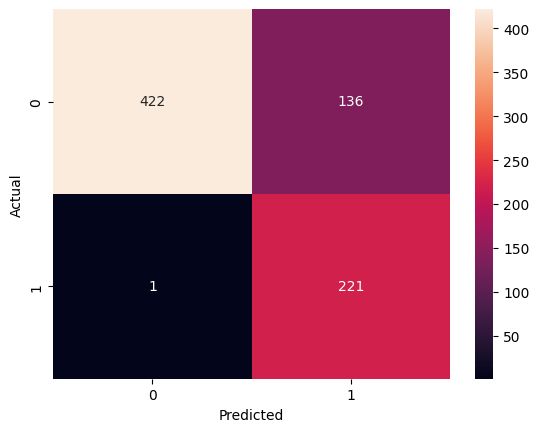

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [73]:
import pandas as pd
importance = pd.Series(rand.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Discount_Applied                         0.392767
Purchase_amount                          0.129193
Age                                      0.120089
Previous_Purchases                       0.119019
Gender                                   0.083429
Review_Rating                            0.037805
Frequency_of_Purchases_Every 3 Months    0.012147
Payment_Method_Venmo                     0.012054
Payment_Method_Cash                      0.011211
Payment_Method_Credit Card               0.010854
Frequency_of_Purchases_Fortnightly       0.010682
Frequency_of_Purchases_Weekly            0.010475
Frequency_of_Purchases_Quarterly         0.010303
Payment_Method_Debit Card                0.010272
Payment_Method_PayPal                    0.010091
Frequency_of_Purchases_Bi-Weekly         0.009867
Frequency_of_Purchases_Monthly           0.009743
dtype: float64